## Overview

This notebook analyzes the benchmark results for Variant 3 by comparing the **small-files** and **compact** layouts across the S, M, and L datasets.

Unlike the previous version, the results are now based on **five runs per size and layout**. Instead of interpreting a single execution, the notebook aggregates repeated runs and computes average values in order to reduce the impact of random variation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

## Input data

The analysis loads one CSV file for each combination of dataset size and layout. Each file contains multiple benchmark runs collected under the same configuration.

The notebook combines these files into a single dataframe, assigns a run index, and keeps the dataset size and layout as grouping variables for the rest of the analysis.

In [2]:
result_files = {
    ('S', 'small'): 'results_s_small.csv',
    ('S', 'compact'): 'results_s_compact.csv',
    ('M', 'small'): 'results_m_small.csv',
    ('M', 'compact'): 'results_m_compact.csv',
    ('L', 'small'): 'results_l_small.csv',
    ('L', 'compact'): 'results_l_compact.csv',
}

frames = []
for (size, layout), path in result_files.items():
    file_path = Path(path)
    part = pd.read_csv(file_path)
    part['size'] = size
    part['layout'] = layout
    part['source_file'] = file_path.name
    part['run_id'] = range(1, len(part) + 1)
    frames.append(part)

df = pd.concat(frames, ignore_index=True)
df['size_order'] = df['size'].map({'S': 1, 'M': 2, 'L': 3})
df = df.sort_values(['size_order', 'layout', 'run_id']).reset_index(drop=True)
df[['size', 'layout', 'run_id', 'source_file', 'upload_elapsed_s', 'listing_elapsed_s', 'query_elapsed_s', 'download_elapsed_s']]

,size,layout,run_id,source_file,upload_elapsed_s,listing_elapsed_s,query_elapsed_s,download_elapsed_s
0,S,compact,1,results_s_compact.csv,2.849,0.016,0.309,0.664
1,S,compact,2,results_s_compact.csv,2.976,0.015,0.360,0.652
2,S,compact,3,results_s_compact.csv,3.149,0.015,0.325,0.646
3,S,compact,4,results_s_compact.csv,3.225,0.017,0.338,0.785
4,S,compact,5,results_s_compact.csv,3.012,0.016,0.390,0.653
5,S,small,1,results_s_small.csv,12.389,0.162,1.379,9.155
6,S,small,2,results_s_small.csv,12.357,0.156,1.306,9.220
7,S,small,3,results_s_small.csv,11.606,0.158,1.405,9.674
8,S,small,4,results_s_small.csv,11.689,0.127,1.252,9.108
9,S,small,5,results_s_small.csv,12.996,0.163,1.341,9.368


In [3]:
run_counts = df.groupby(['size', 'layout']).size().rename('runs').reset_index()
run_counts

,size,layout,runs
0,L,compact,5
1,L,small,5
2,M,compact,5
3,M,small,5
4,S,compact,5
5,S,small,5


## Averaged measurements

To obtain more stable and representative benchmark values, the notebook groups the data by **size** and **layout** and computes the mean of the main performance metrics.

This approach helps smooth out short-term fluctuations caused by system noise, temporary I/O variation, or background activity during individual runs.

In [4]:
metrics_mean = [
    'local_file_count',
    'upload_elapsed_s',
    'upload_throughput_mb_s',
    'listing_object_count',
    'listing_elapsed_s',
    'query_elapsed_s',
    'download_elapsed_s',
    'download_throughput_mb_s',
    'generation_elapsed_s',
    'compaction_elapsed_s',
    'compact_actual_file_count',
    'compact_rows_per_output_file',
    'query_filtered_rows',
    'query_grouped_rows',
]

summary = (df.groupby(['size', 'layout'], as_index=False)[metrics_mean]
             .mean())
summary['size_order'] = summary['size'].map({'S': 1, 'M': 2, 'L': 3})
summary = summary.sort_values(['size_order', 'layout']).reset_index(drop=True)
summary

,size,layout,local_file_count,upload_elapsed_s,upload_throughput_mb_s,listing_object_count,listing_elapsed_s,query_elapsed_s,download_elapsed_s,download_throughput_mb_s,generation_elapsed_s,compaction_elapsed_s,compact_actual_file_count,compact_rows_per_output_file,query_filtered_rows,query_grouped_rows,size_order
0,S,compact,20.000,3.042,34.330,20.000,0.016,0.344,0.680,154.170,25.593,2.826,20.000,"250,000.000","343,968.000",5.000,1
1,S,small,500.000,12.208,8.674,500.000,0.153,1.337,9.305,11.365,26.230,NaN,NaN,NaN,"343,968.000",5.000,1
2,M,compact,100.000,14.902,34.988,100.000,0.051,1.568,4.059,128.687,131.242,13.912,100.000,"250,000.000","1,719,703.000",5.000,2
3,M,small,"2,500.000",63.845,8.282,"2,500.000",0.698,6.125,49.421,10.711,130.880,NaN,NaN,NaN,"1,719,703.000",5.000,2
4,L,compact,400.000,61.086,34.134,400.000,0.155,5.469,16.611,125.902,514.200,51.013,400.000,"250,000.000","6,887,861.000",5.000,3
5,L,small,"10,000.000",254.826,8.301,"10,000.000",2.320,24.882,196.621,10.760,510.728,NaN,NaN,NaN,"6,887,861.000",5.000,3


## Run-to-run variability

In addition to the averages, the notebook also computes the standard deviation of the main metrics. This makes it possible to verify whether the repeated runs are consistent or whether some measurements vary significantly.

If the standard deviation remains small relative to the mean, the averaged result can be considered reliable for interpretation.

In [5]:
variability = (df.groupby(['size', 'layout'])[['upload_elapsed_s', 'listing_elapsed_s', 'query_elapsed_s', 'download_elapsed_s', 'upload_throughput_mb_s', 'download_throughput_mb_s']]
               .agg(['mean', 'std'])
               .round(3))
variability

upload_elapsed_s       listing_elapsed_s       query_elapsed_s  \
                         mean   std              mean   std            mean   
size layout                                                                   
L    compact           61.086 0.864             0.155 0.023           5.469   
     small            254.826 6.953             2.320 0.200          24.882   
M    compact           14.902 0.326             0.051 0.002           1.568   
     small             63.845 1.599             0.698 0.052           6.125   
S    compact            3.042 0.148             0.016 0.001           0.344   
     small             12.208 0.572             0.153 0.015           1.337   

                   download_elapsed_s       upload_throughput_mb_s        \
               std               mean   std                   mean   std   
size layout                                                                
L    compact 0.269             16.611 1.077                 34.134 0.482   
     small   0.528            196.621 6.192                  8.301 0.228   
M    compact 0.126              4.059 0.211                 34.988 0.769   
     small   0.237             49.421 2.194                  8.282 0.207   
S    compact 0.032              0.680 0.059                 34.330 1.675   
     small   0.060              9.305 0.229                  8.674 0.403   

             download_throughput_mb_s         
                                 mean    std  
size layout                                   
L    compact                  125.902  7.628  
     small                     10.760  0.334  
M    compact                  128.687  6.951  
     small                     10.711  0.482  
S    compact                  154.170 12.029  
     small                     11.365  0.274

## Summary table

The summary table reports the averaged benchmark values for each dataset size and layout. It provides a compact view of the object count, upload time, listing time, query time, and download time.

These averaged values are used as the reference numbers for the rest of the notebook.

In [6]:
benchmark_table = summary[['size', 'layout', 'local_file_count', 'upload_elapsed_s', 'listing_elapsed_s', 'query_elapsed_s', 'download_elapsed_s']].copy()
benchmark_table = benchmark_table.rename(columns={
    'local_file_count': 'objects',
    'upload_elapsed_s': 'upload_s',
    'listing_elapsed_s': 'listing_s',
    'query_elapsed_s': 'query_s',
    'download_elapsed_s': 'download_s',
})
benchmark_table = benchmark_table.round({'objects': 0, 'upload_s': 2, 'listing_s': 2, 'query_s': 2, 'download_s': 2})
benchmark_table

,size,layout,objects,upload_s,listing_s,query_s,download_s
0,S,compact,20.000,3.040,0.020,0.340,0.680
1,S,small,500.000,12.210,0.150,1.340,9.300
2,M,compact,100.000,14.900,0.050,1.570,4.060
3,M,small,"2,500.000",63.840,0.700,6.130,49.420
4,L,compact,400.000,61.090,0.160,5.470,16.610
5,L,small,"10,000.000",254.830,2.320,24.880,196.620


## Speedups and reductions

After averaging the repeated runs, the notebook compares the compact layout against the small-files layout. It computes speedup factors, percentage time reductions, and throughput gains for each dataset size.

This makes the comparison more robust than using a single run, because the final values reflect the typical behavior of each configuration rather than an isolated measurement.

In [7]:
paired = summary.pivot(index='size', columns='layout')
paired = paired.sort_index(key=lambda s: s.map({'S': 1, 'M': 2, 'L': 3}))

speedup = pd.DataFrame(index=paired.index)
speedup['query_speedup_x'] = paired[('query_elapsed_s', 'small')] / paired[('query_elapsed_s', 'compact')]
speedup['upload_speedup_x'] = paired[('upload_elapsed_s', 'small')] / paired[('upload_elapsed_s', 'compact')]
speedup['download_speedup_x'] = paired[('download_elapsed_s', 'small')] / paired[('download_elapsed_s', 'compact')]
speedup['listing_speedup_x'] = paired[('listing_elapsed_s', 'small')] / paired[('listing_elapsed_s', 'compact')]
speedup['query_time_reduction_%'] = (1 - paired[('query_elapsed_s', 'compact')] / paired[('query_elapsed_s', 'small')]) * 100
speedup['listing_time_reduction_%'] = (1 - paired[('listing_elapsed_s', 'compact')] / paired[('listing_elapsed_s', 'small')]) * 100
speedup['upload_gain_%'] = (paired[('upload_throughput_mb_s', 'compact')] / paired[('upload_throughput_mb_s', 'small')] - 1) * 100
speedup['download_gain_%'] = (paired[('download_throughput_mb_s', 'compact')] / paired[('download_throughput_mb_s', 'small')] - 1) * 100
speedup = speedup.reset_index().round(3)
speedup

,size,query_speedup_x,upload_speedup_x,download_speedup_x,listing_speedup_x,query_time_reduction_%,listing_time_reduction_%,upload_gain_%,download_gain_%
0,S,3.880,4.013,13.687,9.636,74.227,89.623,295.784,"1,256.496"
1,M,3.907,4.284,12.175,13.630,74.405,92.663,322.449,"1,101.430"
2,L,4.550,4.172,11.837,14.938,78.021,93.306,311.199,"1,070.058"


## Visual comparison

The plots below show the averaged benchmark metrics for the two layouts across the three dataset sizes. They make it easier to compare the overall trends in request time, listing time, upload throughput, and download throughput.

Using averaged values in the plots reduces visual noise and gives a clearer picture of the real performance differences between the layouts.

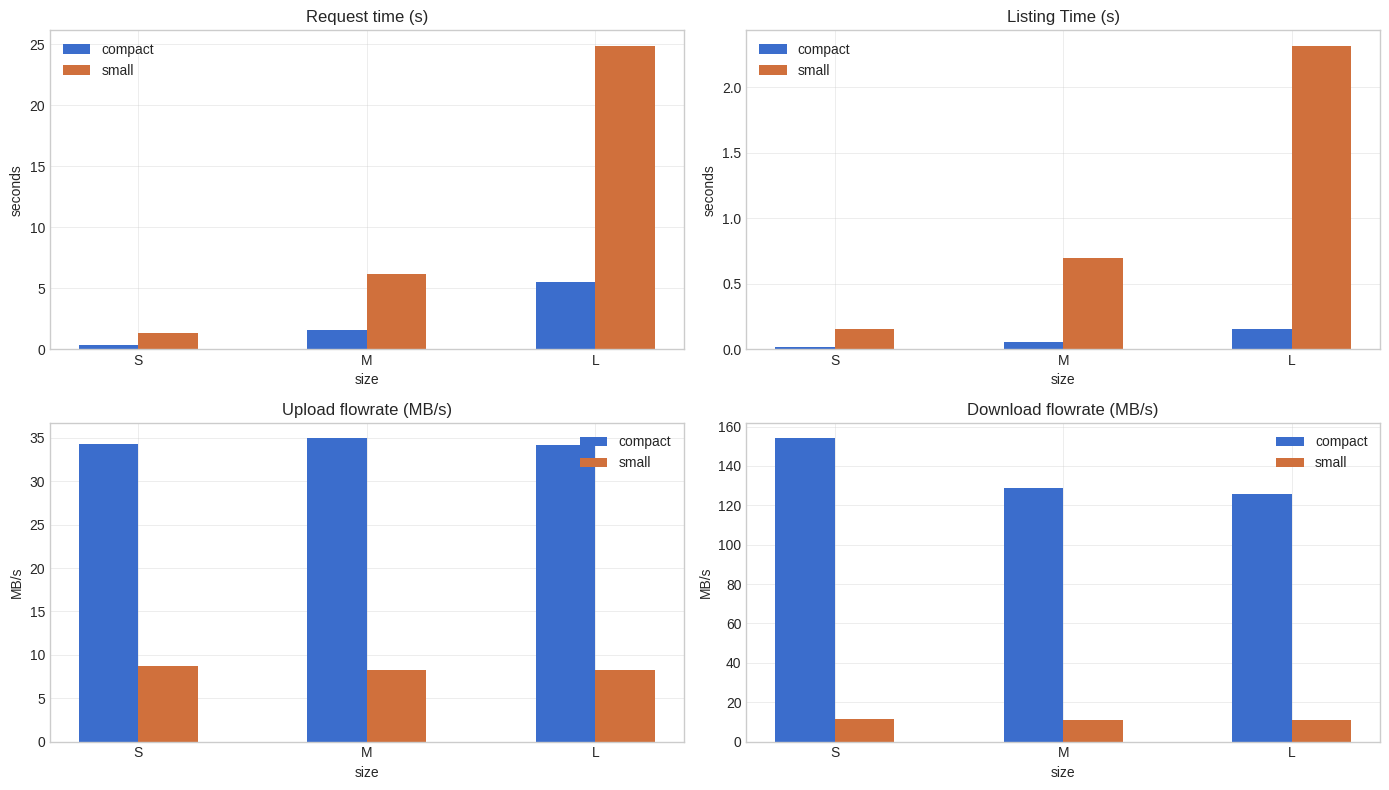

In [8]:
plot_df = summary.copy()
plot_df['size'] = pd.Categorical(plot_df['size'], categories=['S', 'M', 'L'], ordered=True)
plot_df = plot_df.sort_values(['size', 'layout'])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = {'compact': '#3b6dcc', 'small': '#d0703c'}
sizes = ['S', 'M', 'L']
x = range(len(sizes))
width = 0.26

def grouped_bar(ax, metric, title, ylabel):
    compact_vals = plot_df[plot_df['layout'] == 'compact'].set_index('size').loc[sizes, metric]
    small_vals = plot_df[plot_df['layout'] == 'small'].set_index('size').loc[sizes, metric]
    ax.bar([i - width/2 for i in x], compact_vals, width=width, label='compact', color=colors['compact'])
    ax.bar([i + width/2 for i in x], small_vals, width=width, label='small', color=colors['small'])
    ax.set_xticks(list(x), sizes)
    ax.set_xlabel('size')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

grouped_bar(axes[0, 0], 'query_elapsed_s', 'Request time (s)', 'seconds')
grouped_bar(axes[0, 1], 'listing_elapsed_s', 'Listing Time (s)', 'seconds')
grouped_bar(axes[1, 0], 'upload_throughput_mb_s', 'Upload flowrate (MB/s)', 'MB/s')
grouped_bar(axes[1, 1], 'download_throughput_mb_s', 'Download flowrate (MB/s)', 'MB/s')

plt.tight_layout()
plt.show()

## Interpretation

The averaged results confirm the same overall trend as the single-run analysis: the compact layout consistently outperforms the small-files layout across all dataset sizes.

Because the conclusions are now based on five runs per configuration, they are more reliable and less sensitive to occasional fluctuations in execution time.